# Notebook 2: Train Models & Department Forecast
Train 4 models on monthly department spending. Pick winner. Forecast next month per department.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings("ignore")

## 1. Load Data

In [ ]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()
test_info = pd.read_csv("test_info.csv")

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")
print(f"Features: {list(X_train.columns)}")

results = []

Train: 372 rows | Test: 36 rows
Features: ['month', 'year', 'lag_1', 'lag_2', 'lag_3', 'rolling_avg_3', 'trend', 'ytd_spend', 'dept_code']


---
## 2. Model 1: Linear Regression (Baseline)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)
cv = -cross_val_score(lr, X_train, y_train, cv=5, scoring="neg_mean_absolute_error").mean()

print(f"Linear Regression")
print(f"  MAE: EUR {mae:.2f} | RMSE: EUR {rmse:.2f} | R2: {r2:.4f} | CV MAE: EUR {cv:.2f}")

results.append({"name": "Linear Regression", "mae": mae, "rmse": rmse, "r2": r2, "cv_mae": cv, "y_pred": y_pred_lr, "model": lr})

Linear Regression
  MAE: EUR 791.13 | RMSE: EUR 1064.82 | R2: -0.0627 | CV MAE: EUR 642.85


---
## 3. Model 2: Random Forest (Primary)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

print("Tuning Random Forest...")
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid={"n_estimators": [100, 200, 500], "max_depth": [None, 10, 20], "min_samples_split": [2, 5]},
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
print(f"Best: {rf_grid.best_params_}")

rf = rf_grid.best_estimator_
y_pred_rf = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)
cv = -rf_grid.best_score_

print(f"\nRandom Forest")
print(f"  MAE: EUR {mae:.2f} | RMSE: EUR {rmse:.2f} | R2: {r2:.4f} | CV MAE: EUR {cv:.2f}")

results.append({"name": "Random Forest", "mae": mae, "rmse": rmse, "r2": r2, "cv_mae": cv, "y_pred": y_pred_rf, "model": rf})

Tuning Random Forest...
Best: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Random Forest
  MAE: EUR 766.88 | RMSE: EUR 1013.39 | R2: 0.0375 | CV MAE: EUR 688.42


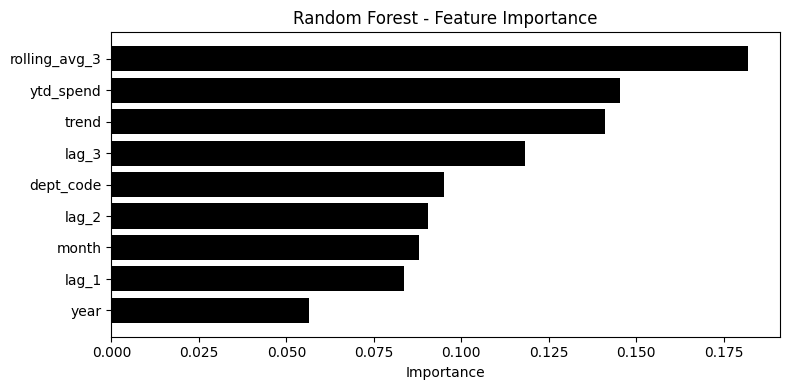

In [ ]:
# Feature importance
feat_imp = pd.DataFrame({"feature": X_train.columns, "importance": rf.feature_importances_})
feat_imp = feat_imp.sort_values("importance", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp["feature"], feat_imp["importance"], color="black")
plt.xlabel("Importance")
plt.title("Random Forest - Feature Importance")
plt.tight_layout()
plt.savefig("plot_feature_importance.png", dpi=150)
plt.show()

---
## 4. Model 3: XGBoost (Comparison)

In [ ]:
from xgboost import XGBRegressor

print("Tuning XGBoost...")
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid={"n_estimators": [100, 200, 500], "learning_rate": [0.01, 0.1, 0.3], "max_depth": [3, 6, 10]},
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
)
xgb_grid.fit(X_train, y_train)
print(f"Best: {xgb_grid.best_params_}")

xgb = xgb_grid.best_estimator_
y_pred_xgb = xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)
cv = -xgb_grid.best_score_

print(f"\nXGBoost")
print(f"  MAE: EUR {mae:.2f} | RMSE: EUR {rmse:.2f} | R2: {r2:.4f} | CV MAE: EUR {cv:.2f}")

results.append({"name": "XGBoost", "mae": mae, "rmse": rmse, "r2": r2, "cv_mae": cv, "y_pred": y_pred_xgb, "model": xgb})

Tuning XGBoost...
Best: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

XGBoost
  MAE: EUR 795.31 | RMSE: EUR 1066.82 | R2: -0.0667 | CV MAE: EUR 647.32


---
## 5. Model 4: LSTM (Experimental)
Skip if PyTorch not installed.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

# Use lag features as the sequence
seq_cols = ["lag_3", "lag_2", "lag_1"]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_tr_s = scaler_X.fit_transform(X_train[seq_cols].values)
X_te_s = scaler_X.transform(X_test[seq_cols].values)
y_tr_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_te_s = scaler_y.transform(y_test.values.reshape(-1, 1))

X_tr_t = torch.FloatTensor(X_tr_s.reshape(-1, 3, 1))
y_tr_t = torch.FloatTensor(y_tr_s)
X_te_t = torch.FloatTensor(X_te_s.reshape(-1, 3, 1))

loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = LSTMModel().to(device)
opt = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

for epoch in range(100):
    lstm_model.train()
    el = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn(lstm_model(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
        el += loss.item()
    if (epoch+1) % 25 == 0:
        print(f"  Epoch {epoch+1}/100 - Loss: {el/len(loader):.6f}")

lstm_model.eval()
with torch.no_grad():
    y_pred_lstm = scaler_y.inverse_transform(lstm_model(X_te_t.to(device)).cpu().numpy()).flatten()

mae = mean_absolute_error(y_test, y_pred_lstm)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2 = r2_score(y_test, y_pred_lstm)

print(f"\nLSTM")
print(f"  MAE: EUR {mae:.2f} | RMSE: EUR {rmse:.2f} | R2: {r2:.4f}")

results.append({"name": "LSTM", "mae": mae, "rmse": rmse, "r2": r2, "cv_mae": None, "y_pred": y_pred_lstm, "model": lstm_model})

  Epoch 25/100 - Loss: 0.028283
  Epoch 50/100 - Loss: 0.029475
  Epoch 75/100 - Loss: 0.027515
  Epoch 100/100 - Loss: 0.027428

LSTM
  MAE: EUR 804.87 | RMSE: EUR 1053.06 | R2: -0.0393


---
## 6. Model Comparison

In [ ]:
comp = pd.DataFrame([{
    "Model": r["name"],
    "MAE (EUR)": round(r["mae"], 2),
    "RMSE (EUR)": round(r["rmse"], 2),
    "R2": round(r["r2"], 4),
    "CV MAE": f"EUR {r['cv_mae']:.2f}" if r["cv_mae"] else "N/A",
} for r in results])

print(comp.to_string(index=False))

winner = min(results, key=lambda x: x["mae"])
print(f"\nWINNER: {winner['name']} (MAE: EUR {winner['mae']:.2f})")

            Model  MAE (EUR)  RMSE (EUR)      R2     CV MAE
Linear Regression     791.13     1064.82 -0.0627 EUR 642.85
    Random Forest     766.88     1013.39  0.0375 EUR 688.42
          XGBoost     795.31     1066.82 -0.0667 EUR 647.32
             LSTM     804.87     1053.06 -0.0393        N/A

WINNER: Random Forest (MAE: EUR 766.88)


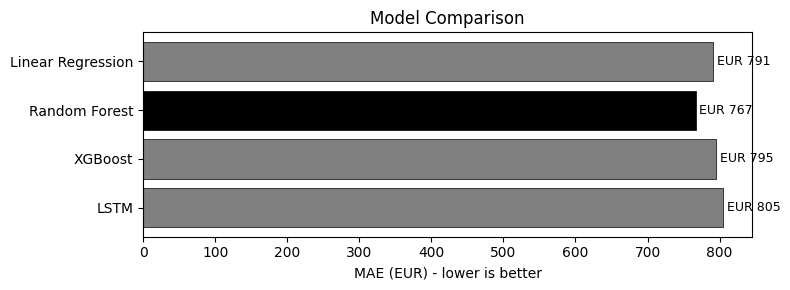

In [ ]:
# Bar chart
names = [r["name"] for r in results]
maes = [r["mae"] for r in results]
colors = ["gray"] * len(results)
colors[maes.index(min(maes))] = "black"

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(names, maes, color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("MAE (EUR) - lower is better")
ax.set_title("Model Comparison")
ax.invert_yaxis()
for bar, v in zip(bars, maes):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f"EUR {v:.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("plot_model_comparison.png", dpi=150)
plt.show()

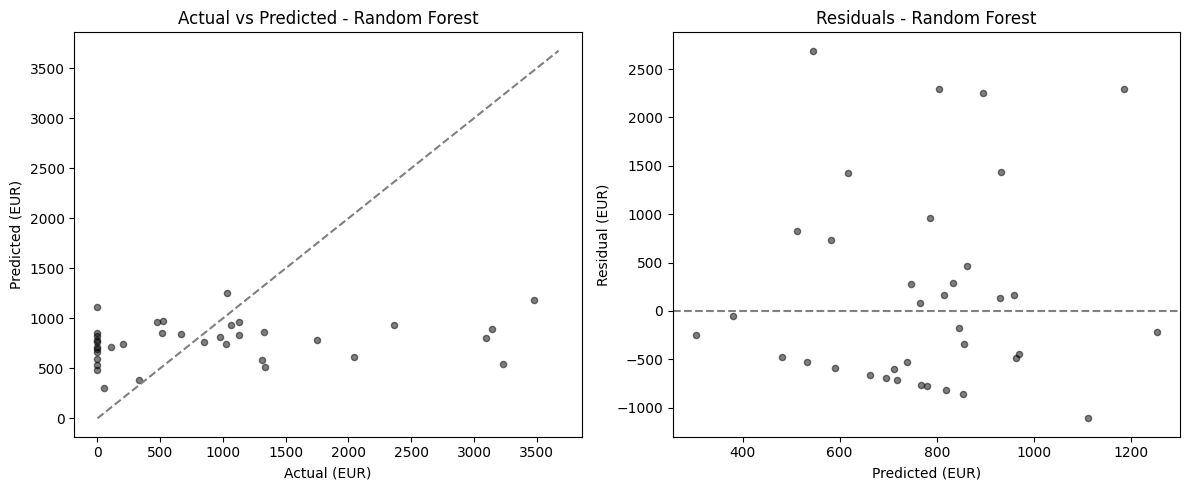

In [ ]:
# Actual vs Predicted + Residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, winner["y_pred"], alpha=0.5, color="black", s=20)
lims = [0, max(y_test.max(), max(winner["y_pred"])) + 200]
axes[0].plot(lims, lims, "--", color="gray")
axes[0].set_xlabel("Actual (EUR)")
axes[0].set_ylabel("Predicted (EUR)")
axes[0].set_title(f"Actual vs Predicted - {winner['name']}")

residuals = y_test.values - winner["y_pred"]
axes[1].scatter(winner["y_pred"], residuals, alpha=0.5, color="black", s=20)
axes[1].axhline(y=0, color="gray", linestyle="--")
axes[1].set_xlabel("Predicted (EUR)")
axes[1].set_ylabel("Residual (EUR)")
axes[1].set_title(f"Residuals - {winner['name']}")

plt.tight_layout()
plt.savefig("plot_actual_vs_predicted.png", dpi=150)
plt.show()

---
## 7. Forecast Next Month Per Department
Use the winning model to predict next month's spending for each department.

In [ ]:
# Load the monthly time series to get the latest data
monthly = pd.read_csv("monthly_department_spending.csv", index_col=0, parse_dates=True)

# Get the best sklearn model
best_sklearn = min([r for r in results if r["name"] != "LSTM"], key=lambda x: x["mae"])
best_model = best_sklearn["model"]
print(f"Using: {best_sklearn['name']}")

depts = [c for c in monthly.columns if c != "Total"]
last_month = monthly.index[-1]
next_month = last_month + pd.DateOffset(months=1)

dept_map = {d: i for i, d in enumerate(sorted(depts))}

print(f"Last data month: {last_month.strftime('%Y-%m')}")
print(f"Predicting: {next_month.strftime('%Y-%m')}")
print(f"Departments: {depts}")

Using: Random Forest
Last data month: 2025-11
Predicting: 2025-12
Departments: ['CX', 'ECX', 'Marketing', 'Recruitment', 'Sales', 'Support']


In [ ]:
# Build prediction input for each department
forecasts = []

for dept in depts:
    series = monthly[dept].values
    
    # Current month = last available month
    current_spend = series[-1]
    
    # Lags
    lag_1 = series[-1]  # most recent month
    lag_2 = series[-2]
    lag_3 = series[-3]
    
    # Rolling avg
    rolling_avg_3 = np.mean(series[-3:])
    
    # Trend
    trend = lag_1 - lag_2
    
    # Year-to-date
    year_start_idx = None
    for i, dt in enumerate(monthly.index):
        if dt.year == next_month.year:
            year_start_idx = i
            break
    if year_start_idx is not None:
        ytd = monthly[dept].iloc[year_start_idx:].sum()
    else:
        ytd = 0
    
    # Build feature row
    row = pd.DataFrame([{
        "month": next_month.month,
        "year": next_month.year,
        "lag_1": lag_1,
        "lag_2": lag_2,
        "lag_3": lag_3,
        "rolling_avg_3": rolling_avg_3,
        "trend": trend,
        "ytd_spend": ytd,
        "dept_code": dept_map[dept],
    }])
    
    predicted = best_model.predict(row)[0]
    predicted = max(predicted, 0)  # no negative spending
    
    # Change vs current month
    if current_spend > 0:
        change_pct = ((predicted - current_spend) / current_spend * 100)
    else:
        change_pct = 0
    
    forecasts.append({
        "department": dept,
        "current_month_spend": round(current_spend, 2),
        "predicted_next_month": round(predicted, 2),
        "change_eur": round(predicted - current_spend, 2),
        "change_pct": round(change_pct, 1),
    })

forecast_df = pd.DataFrame(forecasts)
print("\nDepartment Forecast:")
print(forecast_df.to_string(index=False))


Department Forecast:
 department  current_month_spend  predicted_next_month  change_eur  change_pct
         CX              3145.98                960.08    -2185.90       -69.5
        ECX              1324.84                544.35     -780.49       -58.9
  Marketing              3474.58                995.79    -2478.79       -71.3
Recruitment              3233.95                719.89    -2514.06       -77.7
      Sales              1336.62                396.11     -940.51       -70.4
    Support              3098.74                986.13    -2112.61       -68.2


In [ ]:
# === KPI SUMMARY (matches dashboard design) ===

total_predicted = forecast_df["predicted_next_month"].sum()
total_current = forecast_df["current_month_spend"].sum()
total_change_pct = ((total_predicted - total_current) / total_current * 100) if total_current > 0 else 0

# Utilisation: predicted spend vs average monthly budget
# Use average total monthly spend as baseline
avg_monthly = monthly["Total"].mean()
utilisation = (total_predicted / avg_monthly * 100)
util_current = (total_current / avg_monthly * 100)
util_change = utilisation - util_current

# Remaining: average budget - predicted
remaining = avg_monthly - total_predicted
remaining_current = avg_monthly - total_current
remaining_change = ((remaining - remaining_current) / abs(remaining_current) * 100) if remaining_current != 0 else 0

# Highest spender
highest = forecast_df.loc[forecast_df["predicted_next_month"].idxmax()]

print("ML FORECAST — NEXT MONTH")
print(f"  Predicted Spend:         EUR {total_predicted:,.0f}")
arrow1 = "↑" if total_change_pct > 0 else "↓"
print(f"    {arrow1} {abs(total_change_pct):.0f}% vs this month")
print(f"")
print(f"  Predicted Utilisation:    {utilisation:.0f}%")
arrow2 = "↑" if util_change > 0 else "↓"
print(f"    {arrow2} {abs(util_change):.0f}% vs this month")
print(f"")
print(f"  Predicted Remaining:     EUR {remaining:,.0f}")
arrow3 = "↑" if remaining_change > 0 else "↓"
print(f"    {arrow3} {abs(remaining_change):.0f}% vs this month")
print(f"")
print(f"  Highest Predicted Spender: {highest['department']}")
print(f"    est. EUR {highest['predicted_next_month']:,.0f} next month")


ML FORECAST — NEXT MONTH
  Predicted Spend:         EUR 4,602
    ↓ 71% vs this month

  Predicted Utilisation:    105%
    ↓ 251% vs this month

  Predicted Remaining:     EUR -221
    ↑ 98% vs this month

  Highest Predicted Spender: Marketing
    est. EUR 996 next month


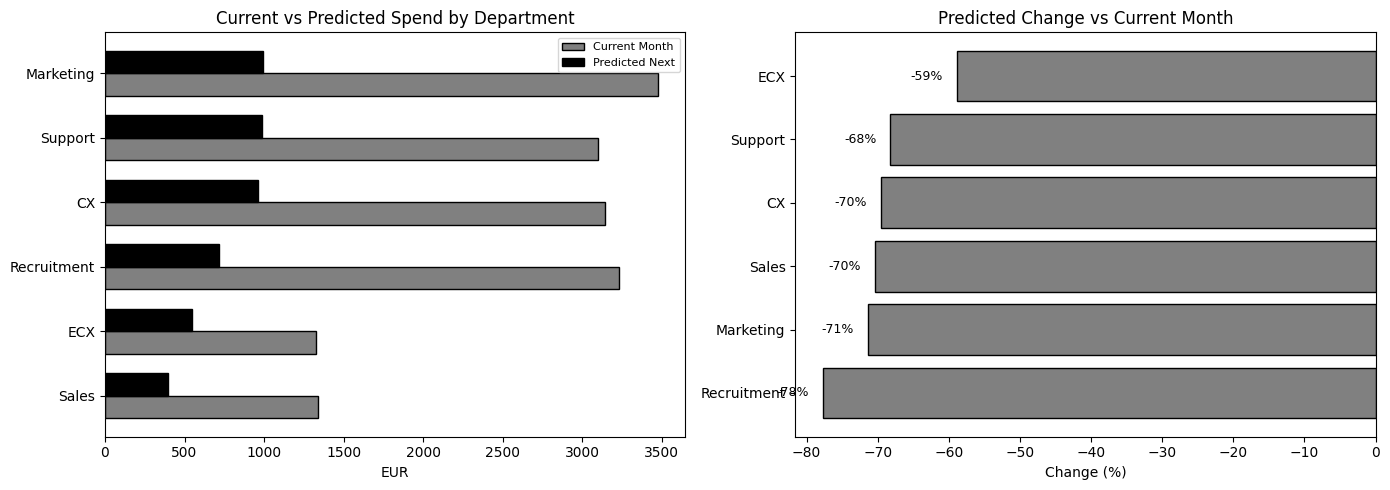

In [ ]:
# Department forecast chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Current vs Predicted by department
dept_sorted = forecast_df.sort_values("predicted_next_month", ascending=True)
y_pos = range(len(dept_sorted))
axes[0].barh(y_pos, dept_sorted["current_month_spend"], height=0.35, label="Current Month", color="gray", edgecolor="black")
axes[0].barh([y + 0.35 for y in y_pos], dept_sorted["predicted_next_month"], height=0.35, label="Predicted Next", color="black", edgecolor="black")
axes[0].set_yticks([y + 0.175 for y in y_pos])
axes[0].set_yticklabels(dept_sorted["department"])
axes[0].set_xlabel("EUR")
axes[0].set_title("Current vs Predicted Spend by Department")
axes[0].legend(fontsize=8)

# Chart 2: Change %
dept_sorted2 = forecast_df.sort_values("change_pct", ascending=True)
colors = ["black" if c > 0 else "gray" for c in dept_sorted2["change_pct"]]
axes[1].barh(dept_sorted2["department"], dept_sorted2["change_pct"], color=colors, edgecolor="black")
axes[1].axvline(x=0, color="black", linewidth=0.5)
axes[1].set_xlabel("Change (%)")
axes[1].set_title("Predicted Change vs Current Month")
for i, (_, row) in enumerate(dept_sorted2.iterrows()):
    sign = "+" if row["change_pct"] > 0 else ""
    axes[1].text(row["change_pct"] + (2 if row["change_pct"] >= 0 else -2), i, 
                f"{sign}{row['change_pct']:.0f}%", va="center", fontsize=9,
                ha="left" if row["change_pct"] >= 0 else "right")

plt.tight_layout()
plt.savefig("plot_department_forecast.png", dpi=150)
plt.show()

---
## 8. Save Everything

In [ ]:
# Models
joblib.dump(lr, "model_linear_regression.pkl")
joblib.dump(rf, "model_random_forest.pkl")
joblib.dump(xgb, "model_xgboost.pkl")
print("Saved: model_linear_regression.pkl, model_random_forest.pkl, model_xgboost.pkl")

try:
    torch.save(lstm_model.state_dict(), "model_lstm.pth")
    print("Saved: model_lstm.pth")
except:
    print("LSTM not saved")

# Results
comp.to_csv("results_comparison.csv", index=False)
forecast_df.to_csv("results_department_forecast.csv", index=False)
print("Saved: results_comparison.csv, results_department_forecast.csv")

print(f"\nDone. Winner: {winner['name']}")

Saved: model_linear_regression.pkl, model_random_forest.pkl, model_xgboost.pkl
Saved: model_lstm.pth
Saved: results_comparison.csv, results_department_forecast.csv

Done. Winner: Random Forest


In [ ]:
import joblib
import pandas as pd

# Load model 1 lần khi server start
model = joblib.load("model_random_forest.pkl")

# Mỗi lần cần predict (khi data update):
df = pd.read_excel("IKB_overview_export.xlsx") 
features = build_features(df)                    
predictions = model.predict(features)              

FileNotFoundError: [Errno 2] No such file or directory: 'IKB_overview_export.xlsx'